<a href="https://colab.research.google.com/github/ValeriiSlynko/IT-STEP-Practice/blob/master/Practice_Pandas/Practice_Overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Дані

In [15]:
import pandas as pd

In [16]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/ITStep-AI/refs/heads/superwised_learning/data/car_price.csv")

In [17]:
df.head()

,mileage,age,engine,horsepower,num_previous_owners,price
0,60675,4,1.6,228,1,18421
1,23671,24,1.7,179,1,11279
2,82893,5,2.3,115,1,10279
3,94692,11,2.4,94,1,9876
4,12509,9,1.8,126,0,19428


# Опис даних

- **mileage** — пробіг автомобіля в кілометрах
- **age** — вік автомобіля в роках
- **engine** — об'єм двигуна автомобіля в літрах
- **horsepower** — потужність двигуна в кінських силах
- **num_previous_owners** — кількість попередніх власників автомобіля
- **price** — ціна автомобіля

Потрібно спрогнозувати **ціну** автомобіля

# Завдання 1
Розділіть дані на ознаки для моделі(Х) та цільову змінну(y)

In [18]:
X = df.drop(columns=["price"])
y = df["price"]

In [19]:
X

,mileage,age,engine,horsepower,num_previous_owners
0,60675,4,1.6,228,1
1,23671,24,1.7,179,1
2,82893,5,2.3,115,1
3,94692,11,2.4,94,1
4,12509,9,1.8,126,0
...,...,...,...,...,...
4755,32010,0,2.4,186,3
4756,55146,6,2.1,247,2
4757,89149,4,2.2,93,1
4758,24565,4,1.0,165,2


In [20]:
y

,price
0,18421
1,11279
2,10279
3,9876
4,19428
...,...
4755,22285
4756,12326
4757,15603
4758,19157


# Завдання 2
Розділіть дані на тренувальну та тестову вибірку

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% даних залишаємо для тестування
    random_state=42    # фіксуємо випадковість для відтворюваності результату
)

print("Тренувальна вибірка:", X_train.shape)
print("Тестова вибірка:", X_test.shape)

Тренувальна вибірка: (3808, 5)
Тестова вибірка: (952, 5)


#Завдання 3
Нетренуйте дерево рішень на тренувальній вибірці

При створенні моделі використовуйте параметри за замовчуванням

In [22]:
from sklearn.tree import DecisionTreeRegressor

model_tree = DecisionTreeRegressor()
model_tree.fit(X_train, y_train)

DecisionTreeRegressor()

# Завдання 4
Спронозуйте ціну автомобіля для тренувальних даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
pred = model_tree.predict(X_train)

# 2. Розраховуємо метрики
mae = mean_absolute_error(y_train, pred)
mse = mean_squared_error(y_train, pred)
rmse = np.sqrt(mse)  # Беремо корінь від MSE
r2 = r2_score(y_train, pred)

print("=== ОСНОВНІ МЕТРИКИ МОДЕЛІ (вартість авто) ===")
print(f"MAE  (Mean Absolute Error): {mae:.2f} ₹ (середня помилка)")
print(f"MSE  (Mean Squared Error):  {mse:.2f} ₹² (квадратична помилка)")
print(f"RMSE (Root MSE):            {rmse:.2f} ₹ (помилка з урахуванням викидів)")
print(f"R² Score:                   {r2:.4f} ({r2*100:.2f}% поясненої дисперсії)")

=== ОСНОВНІ МЕТРИКИ МОДЕЛІ (вартість авто) ===
MAE  (Mean Absolute Error): 0.00 ₹ (середня помилка)
MSE  (Mean Squared Error):  0.00 ₹² (квадратична помилка)
RMSE (Root MSE):            0.00 ₹ (помилка з урахуванням викидів)
R² Score:                   1.0000 (100.00% поясненої дисперсії)


# Завдання 5
Спронозуйте ціну автомобіля для тестових даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
pred = model_tree.predict(X_test)

# 2. Розраховуємо метрики
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)  # Беремо корінь від MSE
r2 = r2_score(y_test, pred)

print("=== ОСНОВНІ МЕТРИКИ МОДЕЛІ (вартість авто) ===")
print(f"MAE  (Mean Absolute Error): {mae:.2f} ₹ (середня помилка)")
print(f"MSE  (Mean Squared Error):  {mse:.2f} ₹² (квадратична помилка)")
print(f"RMSE (Root MSE):            {rmse:.2f} ₹ (помилка з урахуванням викидів)")
print(f"R² Score:                   {r2:.4f} ({r2*100:.2f}% поясненої дисперсії)")

=== ОСНОВНІ МЕТРИКИ МОДЕЛІ (вартість авто) ===
MAE  (Mean Absolute Error): 3029.30 ₹ (середня помилка)
MSE  (Mean Squared Error):  14418854.44 ₹² (квадратична помилка)
RMSE (Root MSE):            3797.22 ₹ (помилка з урахуванням викидів)
R² Score:                   0.5372 (53.72% поясненої дисперсії)


# Завдання 6
Для різних значень параметра `max_depth` натренуйте модель та порахуйте метрику `MAE` на тренувальних та тестових даних

Отримайте відповідно 2 списки -- `train_mae` та `test_mae`
візуалізуйте їх

In [32]:
train_mae = []
test_mae = []

max_depths = range(1, 16)

for depth in max_depths:
  tree = DecisionTreeRegressor(max_depth=depth)
  tree.fit(X_train, y_train)

  train_predict = tree.predict(X_train)
  test_predict = tree.predict(X_test)

  mae_test = mean_absolute_error(y_test, test_predict)
  mae_train = mean_absolute_error(y_train, train_predict)

  train_mae.append(mae_train)
  test_mae.append(mae_test)



In [33]:
train_mae

[3988.062118176598,
 3370.675497242045,
 2923.2265611961425,
 2616.6429313246977,
 2428.453729478045,
 2267.9994315482454,
 2094.89873852778,
 1917.0353092929756,
 1729.781981722951,
 1521.077540852346,
 1290.4022395306245,
 1059.5364874169975,
 844.2458808274205,
 655.211186239721,
 479.25551756194506]

In [34]:
test_mae

[3865.5684419801573,
 3276.1329386307693,
 2841.451556037191,
 2582.0253313989588,
 2434.323528219818,
 2371.0694897265494,
 2353.166857375877,
 2324.709206053187,
 2348.472657589505,
 2469.419333470874,
 2576.12205166353,
 2706.112847537546,
 2709.4809104039023,
 2834.527365659045,
 2845.303555065083]

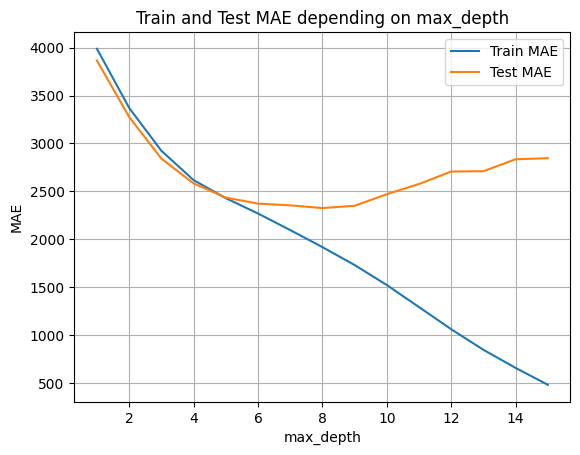

In [35]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_mae, label="Train MAE")
plt.plot(max_depths, test_mae, label="Test MAE")

plt.xlabel("max_depth")
plt.ylabel("MAE")
plt.title("Train and Test MAE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

# Завдання 7
По графіку визначте оптимальне значення параметра `max_depth`

# Завдання 8
Побудуйте такіж графіки для метрик MSE та R2

In [36]:
train_mse = []
test_mse = []

max_depths = range(1, 16)

for depth in max_depths:
  tree = DecisionTreeRegressor(max_depth=depth)
  tree.fit(X_train, y_train)

  train_predict = tree.predict(X_train)
  test_predict = tree.predict(X_test)

  mse_test = mean_squared_error(y_test, test_predict)
  mse_train = mean_squared_error(y_train, train_predict)

  train_mse.append(mse_train)
  test_mse.append(mse_test)

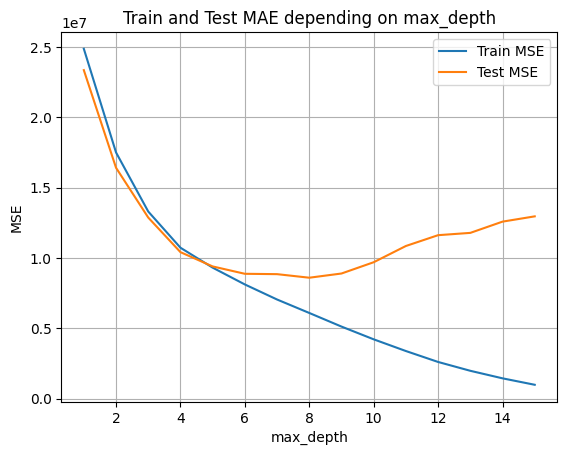

In [39]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_mse, label="Train MSE")
plt.plot(max_depths, test_mse, label="Test MSE")

plt.xlabel("max_depth")
plt.ylabel("MSE")
plt.title("Train and Test MAE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

In [41]:
train_R2 = []
test_R2 = []

max_depths = range(1, 16)

for depth in max_depths:
  tree = DecisionTreeRegressor(max_depth=depth)
  tree.fit(X_train, y_train)

  train_predict = tree.predict(X_train)
  test_predict = tree.predict(X_test)

  R2_test = r2_score(y_test, test_predict)
  R2_train = r2_score(y_train, train_predict)

  train_R2.append(R2_train)
  test_R2.append(R2_test)

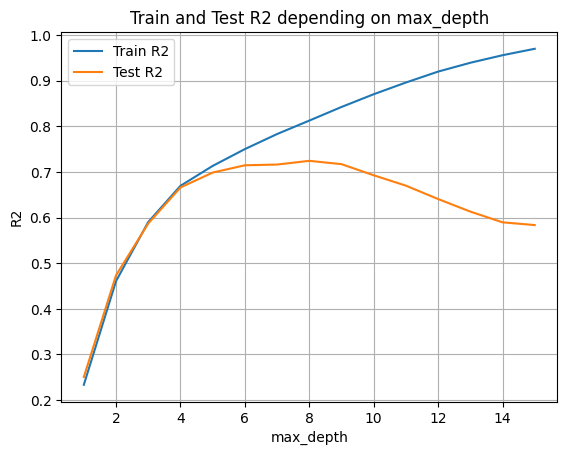

In [43]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_R2, label="Train R2")
plt.plot(max_depths, test_R2, label="Test R2")

plt.xlabel("max_depth")
plt.ylabel("R2")
plt.title("Train and Test R2 depending on max_depth")
plt.legend()
plt.grid()

plt.show()